In [1]:
import cooperative_tasep_lib as tasep
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from joblib import Parallel, delayed

In [3]:
def theoretical(x, kon, koff):
    nom = kon*(1-np.exp(-(kon+koff)*x))
    den = kon+koff
    return nom/den

In [4]:
def main(L, T, kon, koff, kstep, kq, q):
    N=10
    res = np.zeros((N, 10*T+1))
    activated_length = np.zeros((N, 10*T+1))

    for i in range(N):
        data, activation, nn, times, rs, dts = tasep.ssim(L, T, kon, koff, kstep, kq, q)
        res[i, :] = np.mean(data, axis=1)
        activated_length[i, :] = np.mean(activation, axis=1)
    return np.mean(res, axis=0), np.mean(activated_length, axis=0)


In [7]:
data, activation, nn, times, res, dts = tasep.ssim(L, T, kon, koff, kstep, kq, q)

In [9]:
def first_approx(x, kon, koff, l, q):
    return theoretical(x, l*(q-1)*kon+kon, koff)
    

In [12]:
def second(x, Dt, kon, koff, l, q):
    assert(len(x)==len(l))
    y = np.zeros(len(x))
    Q = (q-1)
    for i in range(0, len(x)-1):
        y[i+1] = y[i] + Dt * (kon + kon*Q*l[i]-y[i]*kon-(kon+kon*Q*l[i]-y[i]*kon+koff)*y[i])

    return y

def third(x, Dt, kon, koff, l, q): # Second order
    assert(len(x)==len(l))
    y = np.zeros(len(x))
    Q = (q-1)
    for i in range(0, len(x)-1):
        y[i+1] = y[i] + Dt * (kon + kon*Q*l[i]-(kon+kon*Q*l[i]+koff)*y[i])

    return y

In [63]:
L = 300
T = 100
q = 1
kon = 1
koff = 1
kstep = 100
kq = 100

In [64]:
data_a, sides_a = main(L, T, 1, 1, kstep, kq, 1)
data_b, sides_b = main(L, T, 0.1, 1, kstep, kq, 10)




In [11]:
x = np.arange(0,4,0.1)
y_app = first_approx(x, 0.1, 1, sides_b[:len(x)], 10)

In [65]:
x = np.arange(0,4,0.1)
y_sec = second(x, 0.1, 0.1, 1, sides_b[:len(x)], 10)
y_third = third(x, 0.1, 0.1, 1, sides_b[:len(x)], 10)
# x = np.arange(0,2,0.1)
y_th_high = theoretical(x, 1, 1)
y_th_low = theoretical(x, 0.1, 1)

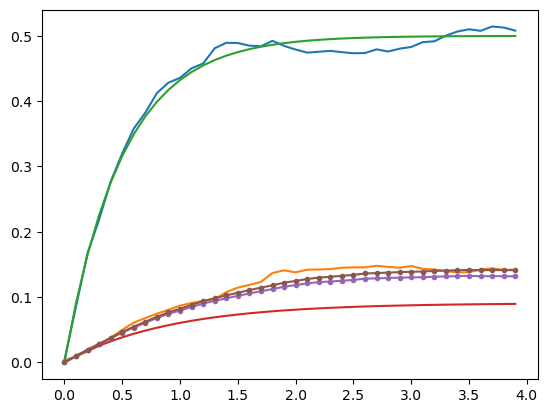

In [66]:
plt.plot(x,data_a[:40])
plt.plot(x,data_b[:40])
plt.plot(x, y_th_high)
plt.plot(x, y_th_low)
# plt.plot(x, y_app)
plt.plot(x, y_sec, marker='.')
plt.plot(x, y_third, marker='.')

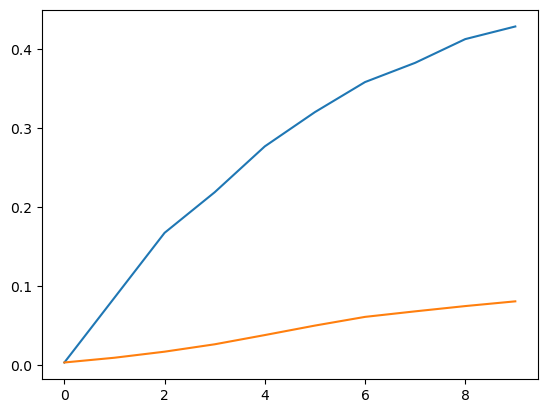

In [67]:
plt.plot(data_a[:10])
plt.plot(data_b[:10])

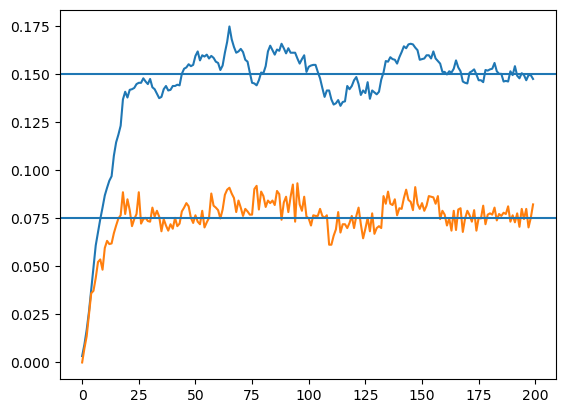

In [69]:
N =200

plt.plot( data_b[:N])

plt.plot(sides_b[:N])

plt.axhline(0.15)
plt.axhline(0.075)

In [72]:
def func (n, s, koff, kstep, kq):
    return koff*n + kstep*n*(1-n-s) - kstep*n*s -kq*s

def func_b (n, s, koff, kstep, kq):
    return koff*n + kstep - kstep*n*s -kq*s

In [74]:
func_b(0.15,0.075, 1,100, 100)

91.525

/tmp/ipykernel_14978/2916241492.py:1: RuntimeWarning: divide by zero encountered in divide
  r = data_b/sides_b


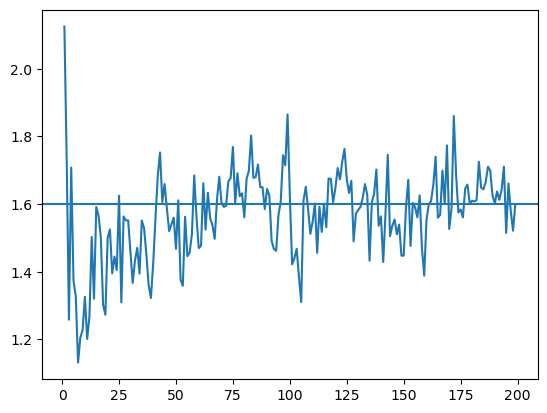

In [35]:
r = data_b/sides_b

plt.plot(r[:200])
plt.axhline(1.6)

In [39]:
data_c = main(L, T, 0.2, 1, kstep, kq, 5)

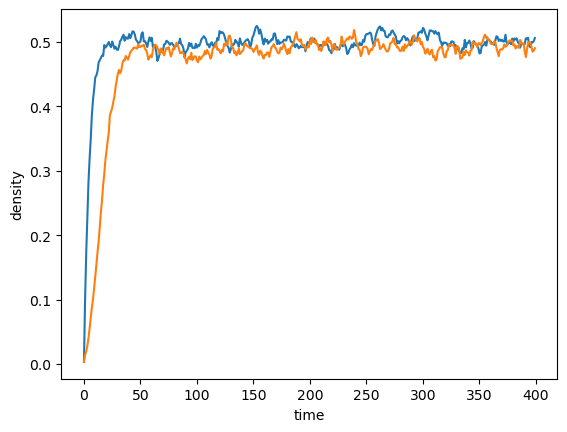

In [51]:
plt.plot(data_a[:400])
plt.plot(data_b[:400])
# plt.plot(data_c[:400])
plt.xlabel("time")
plt.ylabel("density")
plt.savefig("idea.png")

<Figure size 640x480 with 0 Axes>

In [41]:
data_c = main(L, T, 10, 10, kstep, kq, 1)

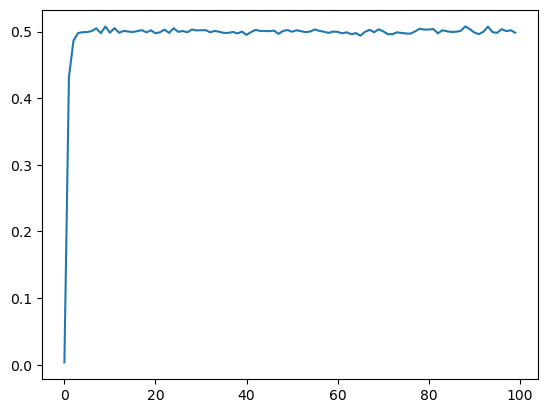

In [43]:
plt.plot(data_c[:100])

In [38]:
def find_80(data, times):
    idx = np.where(data_a>=0.4)[0][0]
    return times[idx]

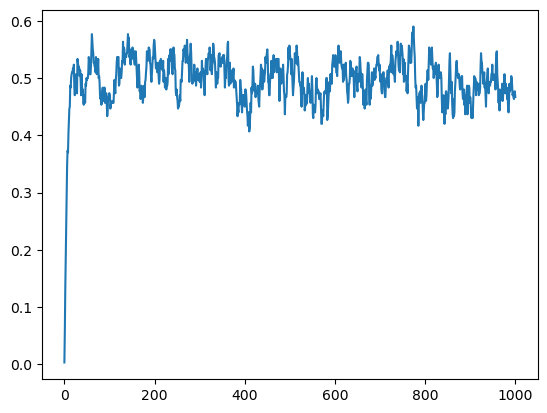

In [4]:
plt.plot(np.mean(data, axis=1))